## Model using 2d protein input and output excitation wavelength and lambda max.

Using python 3.11.14

In [1]:
## Imports
import numpy as np
import pandas as pd
import requests
import json

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch 
import torch
import torch.nn as nn

import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

## We pull the fluorescent protein database

In [2]:
url = "https://www.fpbase.org/api/proteins/?format=json"

response = requests.get(url)
data = response.json()

print(type(data))
print(len(data))

<class 'list'>
1040


Now transform the database to a dataframe 

In [13]:
rows = []

for protein in data:
    
    states = protein.get("states", [])
    if len(states) == 0:
        continue
    
    state = states[0]
    
    rows.append({
        "name": protein.get("name"),
        "FPBASE_Code": protein.get("uuid"),
        "sequence": protein.get("seq"),
        "aggregation_type": protein.get("agg"),
        "excitation": state.get("ex_max"),
        "emission": state.get("em_max"),
        "brightness": state.get("brightness") 
    })

df = pd.DataFrame(rows)
df.head()

,name,FPBASE_Code,sequence,aggregation_type,excitation,emission,brightness
0,10B,RO9XQ,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,,513.0,525.0,NaN
1,11,W92N1,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,,502.0,512.0,NaN
2,(3-F)Tyr-EGFP,2VPWT,SKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFI...,,484.0,514.0,NaN
3,5B,G9FG2,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,,512.0,524.0,NaN
4,A44-KR,D77WT,MEGGPALFQSDMTFKIFIDGEVNGQKFTIVADGSSKFPHGDFNAHA...,,397.0,520.0,NaN


In [21]:
import json
target_uuid = "T33XW"

protein_match = next(
    (p for p in data if p.get("uuid") == target_uuid),
    None
)

print(protein_match)
if protein_match:
    print(json.dumps(protein_match, indent=2))
else:
    print("Protein not found")

{'uuid': 'T33XW', 'name': 'phiLOV2.1', 'slug': 'philov21', 'seq': 'MEKSFVITDPRLPDYPIIFASDGFLELTEYSREEIMGRNARFLQGPETDQATVQKIRDAIRDQRETTVQLINYTKSGKKFWNLLHLQPVRDRKGGLQYFIGVQLVGSDHV', 'ipg_id': None, 'genbank': 'AUS83262', 'uniprot': None, 'pdb': [], 'agg': 'm', 'switch_type': 'b', 'states': [{'slug': 'philov21_default', 'name': 'default', 'ex_max': 451, 'em_max': 501, 'ext_coeff': 13500, 'qy': 0.2, 'pka': 3.0, 'maturation': None, 'lifetime': None, 'brightness': 2.7}], 'transitions': [], 'doi': '10.1101/2021.08.02.454744'}
{
  "uuid": "T33XW",
  "name": "phiLOV2.1",
  "slug": "philov21",
  "seq": "MEKSFVITDPRLPDYPIIFASDGFLELTEYSREEIMGRNARFLQGPETDQATVQKIRDAIRDQRETTVQLINYTKSGKKFWNLLHLQPVRDRKGGLQYFIGVQLVGSDHV",
  "ipg_id": null,
  "genbank": "AUS83262",
  "uniprot": null,
  "pdb": [],
  "agg": "m",
  "switch_type": "b",
  "states": [
    {
      "slug": "philov21_default",
      "name": "default",
      "ex_max": 451,
      "em_max": 501,
      "ext_coeff": 13500,
      "qy": 0.2,
      "pka"

Not fully clean completed so we will need to clean up our database

In [22]:
print(protein_match.keys())

dict_keys(['uuid', 'name', 'slug', 'seq', 'ipg_id', 'genbank', 'uniprot', 'pdb', 'agg', 'switch_type', 'states', 'transitions', 'doi'])


In [25]:
all_keys = set()
for p in data:
    all_keys.update(p.keys())

print(all_keys)

{'ipg_id', 'slug', 'pdb', 'transitions', 'agg', 'genbank', 'name', 'switch_type', 'seq', 'states', 'uuid', 'doi', 'uniprot'}


In [30]:
df_clean = df.dropna(subset=["sequence", "excitation", "emission"])

df_clean.shape

(837, 6)

In [31]:
df_clean.isna().sum()

name             0
sequence         0
chromophore      0
excitation       0
emission         0
brightness     246
dtype: int64

## Not every protein has a brightness data available, we will just use it as a secondary target

We start with building a 1d convolutional neural network

In [36]:
y_emission = df_clean["emission"].values.astype(np.float32)

amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}

MAX_LEN = 300
NUM_AA = len(amino_acids)

def encode_sequence(seq):
    seq = str(seq)[:MAX_LEN]
    
    x = np.zeros((MAX_LEN, NUM_AA), dtype=np.float32)
    
    for i, aa in enumerate(seq):
        if aa in aa_to_idx:
            x[i, aa_to_idx[aa]] = 1.0
    
    return x

X = np.array([encode_sequence(seq) for seq in df_clean["sequence"]])

In [37]:
print(X.shape)
print(y_emission.shape)

(837, 300, 20)
(837,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_emission,
    test_size=0.2,
    random_state=42
)

In [39]:
model = models.Sequential([
    layers.Conv1D(64, 7, activation='relu', input_shape=(MAX_LEN, 20)),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 5, activation='relu'),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 3, activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(1)
])

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [41]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 177490.7188 - mae: 381.7973 - val_loss: 9517.8799 - val_mae: 79.9925
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21635.4043 - mae: 120.6805 - val_loss: 6599.1191 - val_mae: 66.4705
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10903.7422 - mae: 80.7385 - val_loss: 4906.6646 - val_mae: 51.7957
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7750.7246 - mae: 68.1300 - val_loss: 5193.8491 - val_mae: 49.8991
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6689.2290 - mae: 62.7650 - val_loss: 4156.4775 - val_mae: 45.4583
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7000.5142 - mae: 63.5879 - val_loss: 4747.9751 - val_mae: 50.6215
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5824.6299 - mae: 58.3416 - val_loss: 4173.2891 - val_mae: 48.4164
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5866.0503 - mae: 58.7589 - val_loss: 3402.8828 - val_mae: 43

In [42]:
model.evaluate(X_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7554.3848 - mae: 76.6048


[7554.384765625, 76.60481262207031]

MAE of 76 means that on average the mean emission loss is 76 nm away. Not great given that visible light goes from ~400–700 nm

Lets plot results and see what is going on

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


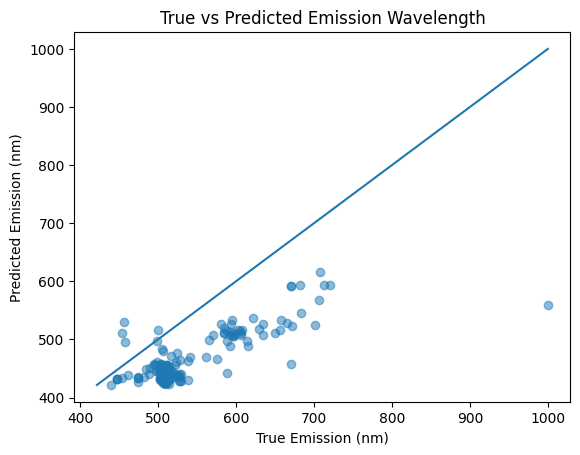

In [44]:
y_pred = model.predict(X_test).flatten()

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("True Emission (nm)")
plt.ylabel("Predicted Emission (nm)")
plt.title("True vs Predicted Emission Wavelength")

# ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

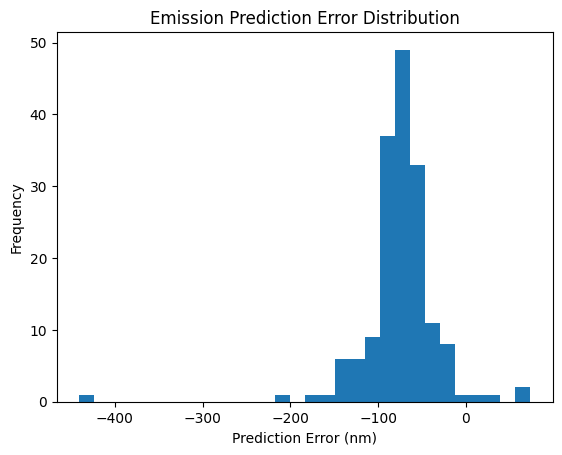

In [45]:
errors = y_pred - y_test

plt.figure()
plt.hist(errors, bins=30)

plt.xlabel("Prediction Error (nm)")
plt.ylabel("Frequency")
plt.title("Emission Prediction Error Distribution")

plt.show()